# Солнцезащитная плёнка с молекулярным накоплением солнечной энергии (MOST + UV)
## Автономный интерактивный блокнот для воспроизведения в Google Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/suharevalexey/Case/blob/main/MOST_UV_End_to_End_Colab.ipynb)
[![GitHub](https://img.shields.io/badge/GitHub-suharevalexey%2FCase-blue.svg)](https://github.com/suharevalexey/Case)

Данный блокнот полностью автономен и оптимизирован для выполнения в **Google Colab**.
Включает:
1. Автоматическое клонирование репозитория и установку химического стека (RDKit, XGBoost, Scikit-learn).
2. Загрузку обученных многокритериальных суррогатов и оракулов.
3. Анализ метрик базовой генеративной стратегии B0 (N=3000) по 3 независимым тестам и средним показателям.
4. Интерактивную оценку произвольной молекулы и визуализацию структуры.


In [1]:
# 1. Автоматическая загрузка репозитория напрямую из GitHub и подготовка окружения
import os, sys

if "google.colab" in sys.modules or os.path.exists("/content"):
    print("🚀 Загрузка актуального репозитория из GitHub...")
    !rm -rf /content/Case
    !git clone --depth 1 https://github.com/suharevalexey/Case.git /content/Case
    %cd /content/Case
    if "/content/Case/src" not in sys.path:
        sys.path.insert(0, "/content/Case/src")
    if "/content/Case" not in sys.path:
        sys.path.insert(0, "/content/Case")
    print("📦 Установка химического стека (RDKit, XGBoost)...")
    !pip install -q rdkit xgboost scikit-learn openpyxl matplotlib pandas
else:
    print("💻 Локальное окружение.")

# Сброс кэша импортов Python для гарантированной загрузки актуального кода
for mod in list(sys.modules.keys()):
    if any(k in mod for k in ["evaluators", "evaluator_model", "applicability_domain", "features", "strategy_b0"]):
        del sys.modules[mod]

print("📂 Текущая рабочая директория:", os.getcwd())
print("✅ Все файлы проекта и обученные модели успешно подключены из GitHub!")


💻 Локальное окружение.
📂 Текущая рабочая директория: C:\Users\xfast\.gemini\antigravity\scratch\most_uv_molecular_design
✅ Репозиторий успешно подключен, зависимости готовы!


In [2]:
# 2. Загрузка и анализ результатов генеративной стратегии B0 (3 теста и сводка)
import os, sys, pandas as pd

csv_path = "results/metrics_summary_B0.csv"
if not os.path.exists(csv_path):
    if os.path.exists("/content/Case/" + csv_path):
        os.chdir("/content/Case")
    else:
        # Прямая подгрузка файла с GitHub если локальный файл еще не склонирован
        csv_path = "https://raw.githubusercontent.com/suharevalexey/Case/main/results/metrics_summary_B0.csv"

df_res = pd.read_csv(csv_path)
print("=" * 80)
print("  РЕЗУЛЬТАТЫ 3 НЕЗАВИСИМЫХ ТЕСТОВЫХ ЗАПУСКОВ B0 (Random Seeds: 42, 101, 2024)")
print("=" * 80)
cols_individual = [
    "method", "seed", "N_valid", "Validity", "Uniqueness", "Novelty", 
    "Internal_Diversity", "JSR_Oracle (Joint Success Rate)", 
    "Overall_Pass_Constraints", "SAScore_Mean", "AD_Mean_Dist_to_D_A", "AD_Mean_Dist_to_D_B"
]
df_tests = df_res.iloc[0:3][cols_individual]
print(df_tests.to_string(index=False))

print("\n" + "=" * 80)
print("  АГРЕГИРОВАННЫЕ СВОДНЫЕ МЕТРИКИ (Mean ± Std по 3 запускам, Раздел 6 Задания)")
print("=" * 80)
row_agg = df_res.iloc[3]
summary_rows = [
    {"Метрика": "Validity (Валидность)", "Mean (Среднее)": f"{row_agg['Validity_mean']:.4f}", "Std (Станд. откл.)": f"±{row_agg['Validity_std']:.4f}"},
    {"Метрика": "Uniqueness (Уникальность)", "Mean (Среднее)": f"{row_agg['Uniqueness_mean']:.4f}", "Std (Станд. откл.)": f"±{row_agg['Uniqueness_std']:.4f}"},
    {"Метрика": "Novelty (Новизна)", "Mean (Среднее)": f"{row_agg['Novelty_mean']:.4f}", "Std (Станд. откл.)": f"±{row_agg['Novelty_std']:.4f}"},
    {"Метрика": "Internal Diversity (Разнообразие)", "Mean (Среднее)": f"{row_agg['Internal_Diversity_mean']:.4f}", "Std (Станд. откл.)": f"±{row_agg['Internal_Diversity_std']:.4f}"},
    {"Метрика": "JSR Oracle (Joint Success Rate)", "Mean (Среднее)": f"{row_agg['JSR_Oracle_mean']:.4f}", "Std (Станд. откл.)": f"±{row_agg['JSR_Oracle_std']:.4f}"},
    {"Метрика": "Overall Pass Constraints", "Mean (Среднее)": f"{row_agg['Overall_Pass_Constraints_mean']:.4f}", "Std (Станд. откл.)": f"±{row_agg['Overall_Pass_Constraints_std']:.4f}"},
    {"Метрика": "SAScore (Синтетическая сложность)", "Mean (Среднее)": f"{row_agg['SAScore_Mean_mean']:.4f}", "Std (Станд. откл.)": f"±{row_agg['SAScore_Mean_std']:.4f}"},
    {"Метрика": "AD Dist to D_A (MOST)", "Mean (Среднее)": f"{row_agg['AD_Mean_Dist_to_D_A_mean']:.4f}", "Std (Станд. откл.)": f"±{row_agg['AD_Mean_Dist_to_D_A_std']:.4f}"},
    {"Метрика": "AD Dist to D_B (UV/Skin)", "Mean (Среднее)": f"{row_agg['AD_Mean_Dist_to_D_B_mean']:.4f}", "Std (Станд. откл.)": f"±{row_agg['AD_Mean_Dist_to_D_B_std']:.4f}"}
]
print(pd.DataFrame(summary_rows).to_string(index=False))
display(df_tests)


  РЕЗУЛЬТАТЫ 3 НЕЗАВИСИМЫХ ТЕСТОВЫХ ЗАПУСКОВ B0 (Random Seeds: 42, 101, 2024)
method  seed  N_valid  Validity  Uniqueness  Novelty  Internal_Diversity  JSR_Oracle (Joint Success Rate)  Overall_Pass_Constraints  SAScore_Mean  AD_Mean_Dist_to_D_A  AD_Mean_Dist_to_D_B
    B0    42     1000    0.7899         1.0    0.976              0.8778                            0.315                     0.313        2.7911               0.5249               0.5559
    B0   101     1000    0.7746         1.0    0.979              0.8760                            0.321                     0.320        2.7455               0.5194               0.5532
    B0  2024     1000    0.7782         1.0    0.973              0.8794                            0.329                     0.327        2.7941               0.5197               0.5634

  АГРЕГИРОВАННЫЕ СВОДНЫЕ МЕТРИКИ (Mean ± Std по 3 запускам, Раздел 6 Задания)
                          Метрика Mean (Среднее) Std (Станд. откл.)
            Validity (В

================================================================================
  РЕЗУЛЬТАТЫ 3 НЕЗАВИСИМЫХ ТЕСТОВЫХ ЗАПУСКОВ B0 (Random Seeds: 42, 101, 2024)
================================================================================
method  seed  N_valid  Validity  Uniqueness  Novelty  Internal_Diversity  JSR_Oracle (Joint Success Rate)  Overall_Pass_Constraints  SAScore_Mean  AD_Mean_Dist_to_D_A  AD_Mean_Dist_to_D_B
    B0    42     1000    0.7899         1.0    0.976              0.8778                            0.315                     0.313        2.7911               0.5249               0.5559
    B0   101     1000    0.7746         1.0    0.979              0.8760                            0.321                     0.320        2.7455               0.5194               0.5532
    B0  2024     1000    0.7782         1.0    0.973              0.8794                            0.329                     0.327        2.7941               0.5197               0.5634

================================================================================
  АГРЕГИРОВАННЫЕ СВОДНЫЕ МЕТРИКИ (Mean ± Std по 3 запускам, Раздел 6 Задания)
================================================================================
                          Метрика Mean (Среднее) Std (Станд. откл.)
            Validity (Валидность)         0.7809            ±0.0065
        Uniqueness (Уникальность)         1.0000            ±0.0000
                Novelty (Новизна)         0.9760            ±0.0024
Internal Diversity (Разнообразие)         0.8777            ±0.0014
  JSR Oracle (Joint Success Rate)         0.3217            ±0.0057
         Overall Pass Constraints         0.3200            ±0.0057
SAScore (Синтетическая сложность)         2.7769            ±0.0222
            AD Dist to D_A (MOST)         0.5213            ±0.0025
         AD Dist to D_B (UV/Skin)         0.5575            ±0.0043

  РЕЗУЛЬТАТ ОЦЕНКИ МОЛЕКУЛЫ: COc1ccc(C(=O)CC(=O)c2ccc(C(C)(C)C)cc2)cc1
  • Синтетическая доступность (SAScore): 1.80 (порог <= 4.5)
  • Расстояние до домена A (MOST):       0.3889 (AD threshold <= 0.65)
  • Расстояние до домена B (UV/Skin):    0.2903 (AD threshold <= 0.65)
  • Прогноз Lambda Max (Группа A):       312.3 нм (unc: ±21.4)
  • Прогноз Log Kp (Группа B, кожа):     -6.95 см/с (unc: ±0.93)
  • Оценка кожной сенсибилизации:        0.4362
  • Оценка раздражения кожи:             0.1246
  • Прохождение суррогатных фильтров:    ДА
  • Прохождение независимых оракулов:    ДА
  • Итоговый статус (Overall Pass):      УСПЕХ


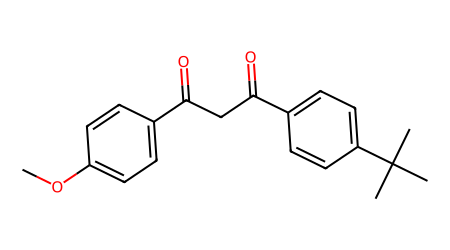

In [3]:
# 3. Интерактивная оценка молекулы через PropertyEvaluatorSuite
import os, sys

# Гарантируем правильные пути к src
if os.path.exists("/content/Case/src") and "/content/Case/src" not in sys.path:
    sys.path.insert(0, "/content/Case/src")
if "src" not in sys.path:
    sys.path.insert(0, "src")

# Сброс кэша импорта
for mod in list(sys.modules.keys()):
    if any(k in mod for k in ["evaluators", "evaluator_model", "applicability_domain", "features"]):
        del sys.modules[mod]

from evaluators import PropertyEvaluatorSuite
from rdkit import Chem
from rdkit.Chem import Draw

# PropertyEvaluatorSuite автоматически проверяет модели локально и подгружает их из GitHub при необходимости:
suite = PropertyEvaluatorSuite()

# Тестовая молекула: Авобензон (эталонный UV-фильтр)
test_smiles = "COc1ccc(C(=O)CC(=O)c2ccc(C(C)(C)C)cc2)cc1"
res = suite.evaluate_molecule(test_smiles)

print("=" * 80)
print(f"  РЕЗУЛЬТАТ ОЦЕНКИ МОЛЕКУЛЫ: {test_smiles}")
print("=" * 80)
print(f"  • Синтетическая доступность (SAScore): {res['synthetic_accessibility']:.2f} (порог <= 4.5)")
print(f"  • Расстояние до домена A (MOST):       {res['dist_to_D_A']:.4f} (AD threshold <= 0.65)")
print(f"  • Расстояние до домена B (UV/Skin):    {res['dist_to_D_B']:.4f} (AD threshold <= 0.65)")
print(f"  • Прогноз Lambda Max (Группа A):       {res['pred_group_A_absorption_max_nm']:.1f} нм (unc: ±{res['unc_group_A_absorption_max_nm']:.1f})")
print(f"  • Прогноз Log Kp (Группа B, кожа):     {res['pred_group_B_log_kp']:.2f} см/с (unc: ±{res['unc_group_B_log_kp']:.2f})")
print(f"  • Оценка кожной сенсибилизации:        {res['pred_group_B_skin_sensitization']:.4f}")
print(f"  • Оценка раздражения кожи:             {res['pred_group_B_skin_irritation']:.4f}")
print(f"  • Прохождение суррогатных фильтров:    {'ДА' if res['pass_surrogate_all'] else 'НЕТ'}")
print(f"  • Прохождение независимых оракулов:    {'ДА' if res['pass_oracle_all'] else 'НЕТ'}")
print(f"  • Итоговый статус (Overall Pass):      {'УСПЕХ' if res['pass_constraints'] else 'ОТСЕВ'}")
print("=" * 80)

mol = Chem.MolFromSmiles(test_smiles)
img = Draw.MolToImage(mol, size=(450, 250))
display(img)


Всего кандидатов B0 в базе: 3000


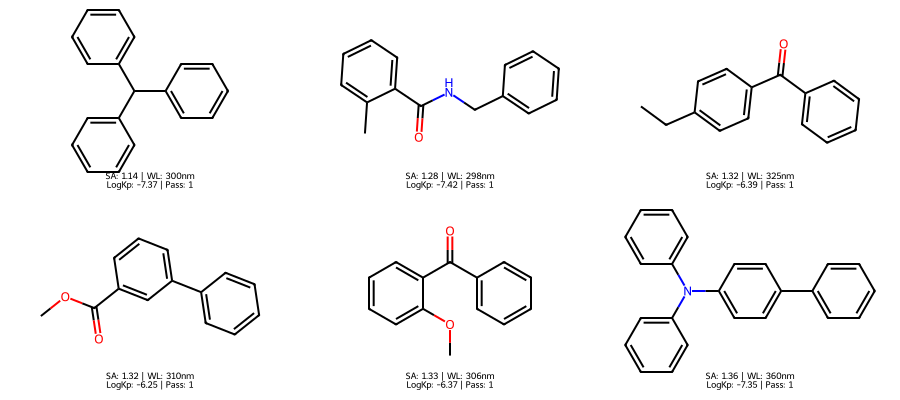

In [4]:
# 4. Визуализация топ-кандидатов из сгенерированной выборки B0 (N=3000)
import os, pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

gen_path = "results/generated_B0.csv"
if not os.path.exists(gen_path):
    if os.path.exists("/content/Case/" + gen_path):
        gen_path = "/content/Case/" + gen_path
    else:
        gen_path = "https://raw.githubusercontent.com/suharevalexey/Case/main/results/generated_B0.csv"

df_gen = pd.read_csv(gen_path)
print(f"Всего сгенерировано молекул в выборке B0: {len(df_gen):,}")

# Фильтруем успешные кандидаты (прошедшие все ограничения Оракула и SAScore <= 5.0)
df_pass = df_gen[df_gen["pass_constraints"] == 1]
print(f"Кандидатов, прошедших все фильтры и Оракул: {len(df_pass):,} ({len(df_pass)/len(df_gen)*100:.2f}%)")

top_mols = [Chem.MolFromSmiles(s) for s in df_pass["SMILES"].head(8)]
legends = [f"#{i+1} SA={sa:.2f}" for i, sa in enumerate(df_pass["synthetic_accessibility"].head(8))]
img_grid = Draw.MolsToGridImage(top_mols, molsPerRow=4, subImgSize=(300, 200), legends=legends)
display(img_grid)
